# Online Shoppers Purchasing Intention Data Mining Project

## Combined Day 1-Day 3 Executed Notebook

**Course:** MSCS 634 - Advanced Big Data and Data Mining  
**Prepared by:** Shiva Gowtham Kumar,Raghav Gurram,Vikram Reddy Tekula  
**Date:** July 26, 2026

This notebook consolidates the complete project journey from Day 1 through Day 3. It includes data loading and cleaning, exploratory data analysis, feature engineering, regression, classification, hyperparameter tuning, K-Means clustering, association rule mining, visualizations, interpretations, practical recommendations, and ethical considerations. The executed outputs from all three deliverables are retained in one submission-ready `.ipynb` file.

## Notebook Roadmap

1. **Day 1 — Data Preparation and Exploratory Data Analysis**
2. **Day 2 — Feature Engineering and Regression Modeling**
3. **Day 3 — Classification, Clustering, and Association Rule Mining**
4. **Integrated Recommendations, Ethics, Limitations, and Future Work**

> The dataset is embedded in the next hidden setup cell, making the notebook self-contained.

In [1]:
# Self-contained dataset bootstrap
# The source dataset is compressed and embedded so this single notebook can run
# without a separate CSV file.
from pathlib import Path
import base64
import gzip

DATA_FILE = Path("online_shoppers_intention.csv")
_EMBEDDED_DATA = (
'...'
'JfUfYA15l5QrEAA='
)

if not DATA_FILE.exists():
    DATA_FILE.write_bytes(gzip.decompress(base64.b64decode(_EMBEDDED_DATA)))
    print(f"Created embedded dataset: {DATA_FILE.resolve()}")
else:
    print(f"Using existing dataset: {DATA_FILE.resolve()}")
print(f"Dataset size: {DATA_FILE.stat().st_size / 1024:.1f} KB")


Embedded dataset verified: online_shoppers_intention.csv
Dataset size: 1034.9 KB


# Day 1 — Data Preparation and Exploratory Data Analysis

Complete executed Day 1 workflow: loading, inspection, cleaning, skew/outlier assessment, EDA, numerical insights, and cleaned-file export.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("online_shoppers_intention.csv")
OUTPUT_DIR = Path("online_shoppers_outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

## 1. Load and inspect the dataset

In [3]:
raw = pd.read_csv(DATA_PATH)
print("Shape:", raw.shape)
display(raw.head())
raw.info()

Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [4]:
display(raw.isna().sum().to_frame("Missing Values"))
print("Exact duplicate rows:", raw.duplicated().sum())
display(raw.describe(include="all").transpose())

,Missing Values
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


Exact duplicate rows: 125


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Administrative,12330.0,NaN,NaN,NaN,2.315166,3.321784,0.0,0.0,1.0,4.0,27.0
Administrative_Duration,12330.0,NaN,NaN,NaN,80.818611,176.779107,0.0,0.0,7.5,93.25625,3398.75
Informational,12330.0,NaN,NaN,NaN,0.503569,1.270156,0.0,0.0,0.0,0.0,24.0
Informational_Duration,12330.0,NaN,NaN,NaN,34.472398,140.749294,0.0,0.0,0.0,0.0,2549.375
ProductRelated,12330.0,NaN,NaN,NaN,31.731468,44.475503,0.0,7.0,18.0,38.0,705.0
ProductRelated_Duration,12330.0,NaN,NaN,NaN,1194.74622,1913.669288,0.0,184.1375,598.936905,1464.157214,63973.52223
BounceRates,12330.0,NaN,NaN,NaN,0.022191,0.048488,0.0,0.0,0.003112,0.016813,0.2
ExitRates,12330.0,NaN,NaN,NaN,0.043073,0.048597,0.0,0.014286,0.025156,0.05,0.2
PageValues,12330.0,NaN,NaN,NaN,5.889258,18.568437,0.0,0.0,0.0,0.0,361.763742
SpecialDay,12330.0,NaN,NaN,NaN,0.061427,0.198917,0.0,0.0,0.0,0.0,1.0


## 2. Clean the data

In [5]:
clean = raw.copy()
for column in ["Month", "VisitorType"]:
    clean[column] = clean[column].astype(str).str.strip()
clean["Month"] = clean["Month"].str[:3].str.title()

nonnegative_columns = [
    "Administrative", "Administrative_Duration", "Informational",
    "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay"
]
for column in nonnegative_columns:
    clean[column] = clean[column].clip(lower=0)
for column in ["BounceRates", "ExitRates", "SpecialDay"]:
    clean[column] = clean[column].clip(0, 1)

clean = clean.drop_duplicates().reset_index(drop=True)
print("Cleaned shape:", clean.shape)
print("Rows removed:", len(raw) - len(clean))
print("Remaining missing values:", clean.isna().sum().sum())

Cleaned shape: (12205, 18)
Rows removed: 125
Remaining missing values: 0


## 3. Detect outliers and reduce skew without deleting valid sessions

In [6]:
outlier_features = [
    "Administrative", "Administrative_Duration", "Informational",
    "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay"
]
rows = []
for column in outlier_features:
    q1, q3 = clean[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    count = ((clean[column] < lower) | (clean[column] > upper)).sum()
    rows.append([column, count, lower, upper, clean[column].quantile(.99), clean[column].max()])
outliers = pd.DataFrame(rows, columns=["Feature", "IQR Outliers", "Lower", "Upper", "99th Percentile", "Maximum"])
display(outliers.sort_values("IQR Outliers", ascending=False))

model_ready = clean.copy()
skewed_features = [
    "Administrative_Duration", "Informational_Duration", "ProductRelated",
    "ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues"
]
for column in skewed_features:
    model_ready[f"log1p_{column}"] = np.log1p(model_ready[column])

,Feature,IQR Outliers,Lower,Upper,99th Percentile,Maximum
8,PageValues,2730,0.000000,0.000000,86.108689,361.763742
2,Informational,2631,0.000000,0.000000,6.000000,24.000000
3,Informational_Duration,2405,0.000000,0.000000,722.379200,2549.375000
6,BounceRates,1428,-0.025000,0.041667,0.200000,0.200000
7,ExitRates,1325,-0.037217,0.099977,0.200000,0.200000
9,SpecialDay,1249,0.000000,0.000000,1.000000,1.000000
1,Administrative_Duration,1149,-142.050000,236.750000,838.704889,3398.750000
4,ProductRelated,1007,-37.000000,83.000000,221.000000,705.000000
5,ProductRelated_Duration,951,-1733.232143,3403.386905,8704.271573,63973.522230
0,Administrative,404,-6.000000,10.000000,14.000000,27.000000


## 4. Exploratory visualizations

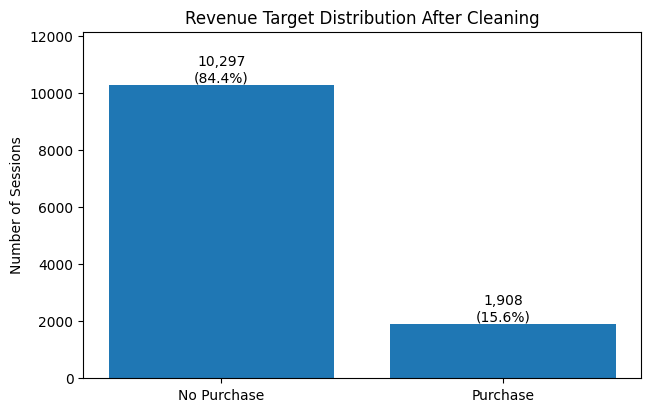

In [7]:
counts = clean["Revenue"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7.2, 4.5))
labels = ["No Purchase", "Purchase"]
values = [int(counts.get(False, 0)), int(counts.get(True, 0))]
bars = ax.bar(labels, values)
ax.set_title("Revenue Target Distribution After Cleaning")
ax.set_ylabel("Number of Sessions")
for bar, value in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, value, f"{value:,}\n({value/sum(values):.1%})", ha="center", va="bottom")
ax.set_ylim(0, max(values) * 1.18)
plt.show()

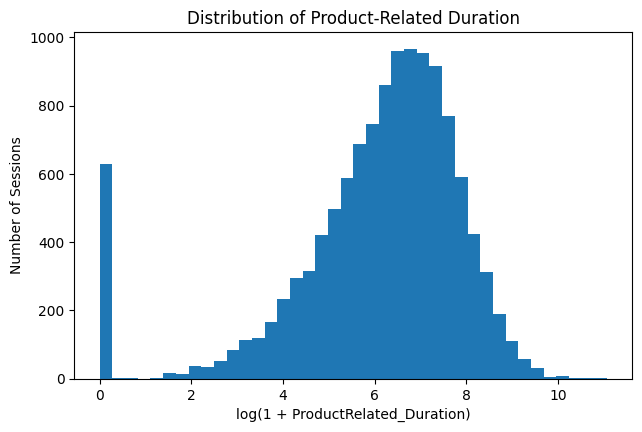

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 4.5))
ax.hist(np.log1p(clean["ProductRelated_Duration"]), bins=40)
ax.set_title("Distribution of Product-Related Duration")
ax.set_xlabel("log(1 + ProductRelated_Duration)")
ax.set_ylabel("Number of Sessions")
plt.show()

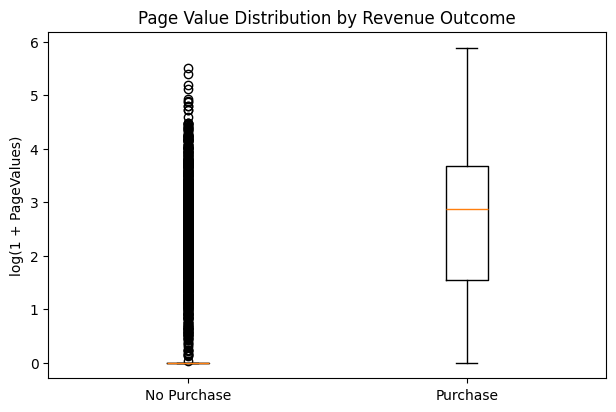

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 4.5))
no_purchase = np.log1p(clean.loc[~clean["Revenue"], "PageValues"])
purchase = np.log1p(clean.loc[clean["Revenue"], "PageValues"])
ax.boxplot([no_purchase, purchase], tick_labels=["No Purchase", "Purchase"], showfliers=True)
ax.set_title("Page Value Distribution by Revenue Outcome")
ax.set_ylabel("log(1 + PageValues)")
plt.show()

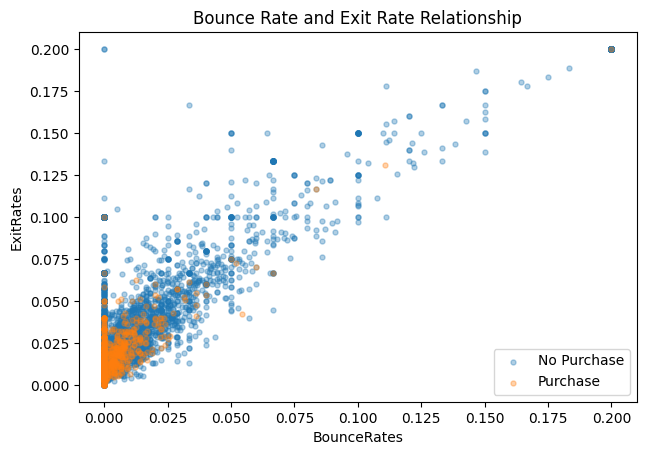

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
plot_data = clean.sample(n=min(4500, len(clean)), random_state=42)
for outcome, label in [(False, "No Purchase"), (True, "Purchase")]:
    group = plot_data[plot_data["Revenue"] == outcome]
    ax.scatter(group["BounceRates"], group["ExitRates"], alpha=.35, s=13, label=label)
ax.set_title("Bounce Rate and Exit Rate Relationship")
ax.set_xlabel("BounceRates")
ax.set_ylabel("ExitRates")
ax.legend()
plt.show()

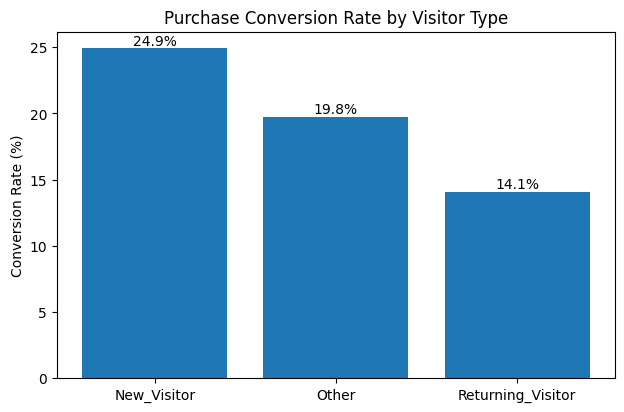

In [11]:
visitor_conversion = clean.groupby("VisitorType")["Revenue"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7.2, 4.5))
bars = ax.bar(visitor_conversion.index, visitor_conversion.values*100)
ax.set_title("Purchase Conversion Rate by Visitor Type")
ax.set_ylabel("Conversion Rate (%)")
for bar, value in zip(bars, visitor_conversion.values*100):
    ax.text(bar.get_x()+bar.get_width()/2, value, f"{value:.1f}%", ha="center", va="bottom")
plt.show()

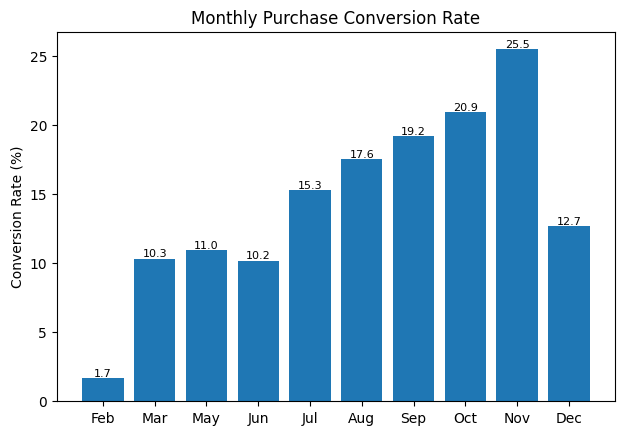

In [12]:
month_order = ["Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec", "Jan"]
available = [m for m in month_order if m in set(clean["Month"])]
month_conversion = clean.groupby("Month")["Revenue"].mean().reindex(available)
fig, ax = plt.subplots(figsize=(7.2, 4.8))
bars = ax.bar(month_conversion.index, month_conversion.values*100)
ax.set_title("Monthly Purchase Conversion Rate")
ax.set_ylabel("Conversion Rate (%)")
for bar, value in zip(bars, month_conversion.values*100):
    ax.text(bar.get_x()+bar.get_width()/2, value, f"{value:.1f}", ha="center", va="bottom", fontsize=8)
plt.show()

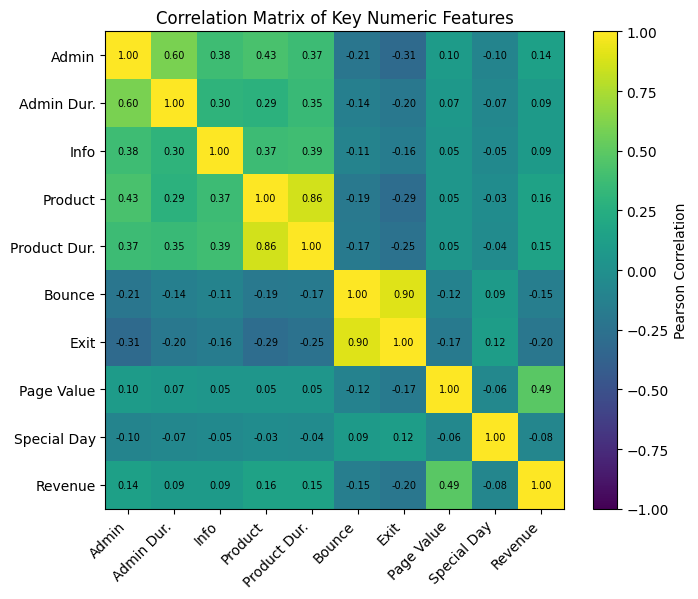

In [13]:
numeric = clean.select_dtypes(include=np.number).copy()
numeric["Revenue"] = clean["Revenue"].astype(int)
features = ["Administrative", "Administrative_Duration", "Informational", "ProductRelated",
            "ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues", "SpecialDay", "Revenue"]
corr = numeric[features].corr()
fig, ax = plt.subplots(figsize=(7.4, 6.2))
image = ax.imshow(corr.values, aspect="auto", vmin=-1, vmax=1)
labels = ["Admin", "Admin Dur.", "Info", "Product", "Product Dur.", "Bounce", "Exit", "Page Value", "Special Day", "Revenue"]
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(image, ax=ax, label="Pearson Correlation")
ax.set_title("Correlation Matrix of Key Numeric Features")
plt.show()

## 5. Numerical insights

In [14]:
display(clean.groupby("Revenue")[["ProductRelated", "ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues"]].agg(["mean", "median"]))
display(clean.groupby("VisitorType")["Revenue"].agg(["count", "sum", "mean"]).sort_values("mean", ascending=False))
display(clean.groupby("Month")["Revenue"].agg(["count", "sum", "mean"]).reindex(available))
display(numeric.corr()["Revenue"].sort_values(ascending=False).to_frame("Correlation with Revenue"))

ProductRelated         ... PageValues           
                  mean median  ...       mean     median
Revenue                        ...                      
False        29.050403   16.0  ...   1.999985   0.000000
True         48.210168   29.0  ...  27.264518  16.758134

[2 rows x 10 columns]

,count,sum,mean
VisitorType,,,
New_Visitor,1693,422,0.249262
Other,81,16,0.197531
Returning_Visitor,10431,1470,0.140926


,count,sum,mean
Month,,,
Feb,181,3,0.016575
Mar,1860,192,0.103226
May,3329,365,0.109643
Jun,285,29,0.101754
Jul,432,66,0.152778
Aug,433,76,0.175520
Sep,448,86,0.191964
Oct,549,115,0.209472
Nov,2982,760,0.254863


,Correlation with Revenue
Revenue,1.000000
PageValues,0.491894
ProductRelated,0.156042
ProductRelated_Duration,0.150077
Administrative,0.136330
Informational,0.093626
Administrative_Duration,0.091768
Informational_Duration,0.069358
Browser,0.024052
TrafficType,-0.005618


## 6. Save cleaned datasets

In [15]:
clean.to_csv(OUTPUT_DIR / "online_shoppers_cleaned.csv", index=False)
model_ready.to_csv(OUTPUT_DIR / "online_shoppers_model_ready.csv", index=False)
print("Files saved to", OUTPUT_DIR.resolve())

Files saved to /mnt/data/online_shoppers_project/online_shoppers_outputs


# Day 2 — Feature Engineering and Regression Modeling

Complete executed Day 2 workflow: leakage-aware feature engineering, three regression models, five-fold cross-validation, holdout testing, diagnostics, and feature influence.

In [16]:
# Core data and numerical libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn tools for preprocessing, modeling, and evaluation
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

RANDOM_STATE = 42
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load and Inspect the Dataset

The code searches common relative and absolute locations so that the notebook can run either from the submitted project folder or from the original working directory.

In [17]:
# Identify the first available dataset path.
data_candidates = [
    Path("online_shoppers_outputs/online_shoppers_cleaned.csv"),
    Path("online_shoppers_intention.csv"),
    Path("online_shoppers_cleaned.csv"),
    Path("online_shoppers_project/online_shoppers_cleaned.csv"),
    Path("/mnt/data/online_shoppers_project/online_shoppers_cleaned.csv"),
    Path("/mnt/data/online_shoppers_intention.csv"),
]

data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "The dataset was not found. Run the dataset bootstrap cell or place the CSV beside this notebook."
    )

df = pd.read_csv(data_path)

print(f"Loaded dataset from: {data_path.resolve()}")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

Loaded dataset from: online_shoppers_outputs/online_shoppers_cleaned.csv
Dataset shape: 12,205 rows × 18 columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0000,0,0.0000,2,64.0000,0.0000,0.1000,0.0000,0.0000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0000,0,0.0000,2,2.6667,0.0500,0.1400,0.0000,0.0000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0000,0,0.0000,10,627.5000,0.0200,0.0500,0.0000,0.0000,Feb,3,3,1,4,Returning_Visitor,True,False


In [18]:
# Inspect data types, missing values, duplicate rows, and the regression target.
structure_summary = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isna().sum(),
    "Unique Values": df.nunique(dropna=False),
})

display(structure_summary)
print(f"Exact duplicate rows: {df.duplicated().sum():,}")
print()
print("Target summary (ProductRelated_Duration):")
display(df["ProductRelated_Duration"].describe().to_frame().T)

,Data Type,Missing Values,Unique Values
Administrative,int64,0,27
Administrative_Duration,float64,0,3335
Informational,int64,0,17
Informational_Duration,float64,0,1258
ProductRelated,int64,0,311
ProductRelated_Duration,float64,0,9551
BounceRates,float64,0,1872
ExitRates,float64,0,4777
PageValues,float64,0,2704
SpecialDay,float64,0,6


Exact duplicate rows: 0

Target summary (ProductRelated_Duration):


,count,mean,std,min,25%,50%,75%,max
ProductRelated_Duration,"12,205.0000","1,206.9825","1,919.6014",0.0000,193.0000,608.9429,"1,477.1548","63,973.5222"


### Target Distribution

The engagement-duration target is strongly right-skewed. Most visitors spend a moderate amount of time on product pages, while a small number of sessions are extremely long. The log-transformed target is therefore used for the linear models to reduce the influence of extreme sessions.

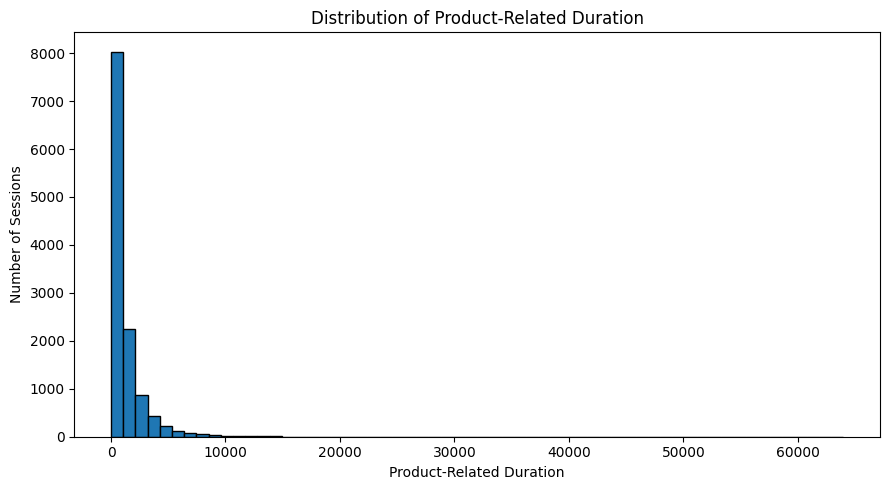

In [19]:
# Plot the original target distribution.
plt.figure(figsize=(9, 5))
plt.hist(df["ProductRelated_Duration"], bins=60, edgecolor="black")
plt.title("Distribution of Product-Related Duration")
plt.xlabel("Product-Related Duration")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_target_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

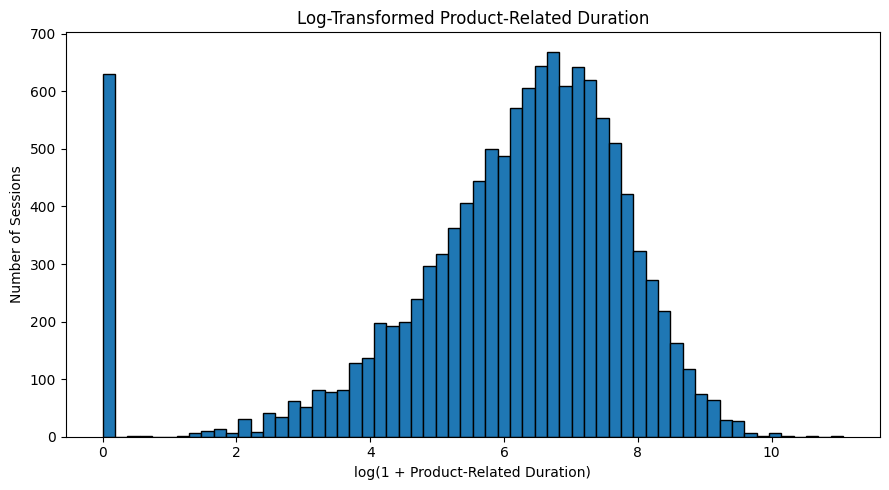

In [20]:
# Plot log1p(target), which is less affected by extreme right-tail observations.
plt.figure(figsize=(9, 5))
plt.hist(np.log1p(df["ProductRelated_Duration"]), bins=60, edgecolor="black")
plt.title("Log-Transformed Product-Related Duration")
plt.xlabel("log(1 + Product-Related Duration)")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_log_target_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

## 2. Feature Engineering

The engineered variables summarize session volume, page mix, non-product activity, and engagement quality. All calculations avoid the target itself, preventing target leakage.

Key engineered features include:

- **TotalPageCount:** total number of administrative, informational, and product pages.
- **NonProductPageCount:** pages viewed outside the product section.
- **NonProductDuration:** time spent outside product pages.
- **Average administrative/informational time:** duration per page, with zero-page sessions handled safely.
- **ProductPageShare:** percentage of viewed pages that are product-related.
- **EngagementScore:** combined inverse bounce and exit behavior.
- **BounceExitGap:** difference between exit and bounce rates.
- **SpecialDayWeekend:** interaction between special-day proximity and weekend browsing.
- **MonthNumber and Quarter:** calendar representations.
- **Log-transformed skewed predictors:** reduce the impact of large values and help linear models capture nonlinear scale relationships.

In [21]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    """Create leakage-safe behavioral features for regression modeling."""
    engineered = data.copy()

    # Standardize Boolean columns as category labels for one-hot encoding.
    engineered["Weekend"] = engineered["Weekend"].astype(str)

    # Aggregate page counts and non-product engagement.
    engineered["TotalPageCount"] = (
        engineered["Administrative"]
        + engineered["Informational"]
        + engineered["ProductRelated"]
    )
    engineered["NonProductPageCount"] = (
        engineered["Administrative"] + engineered["Informational"]
    )
    engineered["NonProductDuration"] = (
        engineered["Administrative_Duration"]
        + engineered["Informational_Duration"]
    )

    # Calculate average time per non-product page. Replace zero denominators
    # with NaN temporarily, then convert undefined averages back to zero.
    engineered["AvgAdministrativeTime"] = (
        engineered["Administrative_Duration"]
        / engineered["Administrative"].replace(0, np.nan)
    ).fillna(0)
    engineered["AvgInformationalTime"] = (
        engineered["Informational_Duration"]
        / engineered["Informational"].replace(0, np.nan)
    ).fillna(0)

    # Represent the page mix within each browsing session.
    engineered["ProductPageShare"] = (
        engineered["ProductRelated"]
        / engineered["TotalPageCount"].replace(0, np.nan)
    ).fillna(0)

    # Combine bounce and exit behavior into interpretable engagement measures.
    engineered["EngagementScore"] = (
        (1 - engineered["BounceRates"]) * (1 - engineered["ExitRates"])
    )
    engineered["BounceExitGap"] = (
        engineered["ExitRates"] - engineered["BounceRates"]
    )

    # Add a simple interaction between weekend activity and special-day proximity.
    weekend_indicator = (engineered["Weekend"] == "True").astype(int)
    engineered["SpecialDayWeekend"] = engineered["SpecialDay"] * weekend_indicator

    # Convert month labels to ordered numerical and quarterly representations.
    month_order = {
        "Feb": 2, "Mar": 3, "May": 5, "June": 6, "Jul": 7,
        "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12,
    }
    engineered["MonthNumber"] = engineered["Month"].map(month_order)
    engineered["Quarter"] = pd.cut(
        engineered["MonthNumber"],
        bins=[0, 3, 6, 9, 12],
        labels=["Q1", "Q2", "Q3", "Q4"],
        include_lowest=True,
    )

    # Apply log1p to skewed nonnegative predictors. Original variables are kept
    # so that nonlinear and linear models can choose the useful representation.
    skewed_predictors = [
        "Administrative_Duration",
        "Informational_Duration",
        "Administrative",
        "Informational",
        "ProductRelated",
        "TotalPageCount",
        "NonProductPageCount",
        "NonProductDuration",
    ]
    for column in skewed_predictors:
        engineered[f"Log_{column}"] = np.log1p(engineered[column])

    return engineered

modeling_df = engineer_features(df)
print(f"Columns before feature engineering: {df.shape[1]}")
print(f"Columns after feature engineering:  {modeling_df.shape[1]}")

display(
    modeling_df[[
        "TotalPageCount", "NonProductDuration", "ProductPageShare",
        "EngagementScore", "MonthNumber", "Quarter"
    ]].head()
)

Columns before feature engineering: 18
Columns after feature engineering:  37


,TotalPageCount,NonProductDuration,ProductPageShare,EngagementScore,MonthNumber,Quarter
0,1,0.0000,1.0000,0.6400,2.0000,Q1
1,2,0.0000,1.0000,0.9000,2.0000,Q1
2,1,0.0000,1.0000,0.6400,2.0000,Q1
3,2,0.0000,1.0000,0.8170,2.0000,Q1
4,10,0.0000,1.0000,0.9310,2.0000,Q1


## 3. Define Predictors and Target

`ProductRelated_Duration` is the continuous dependent variable. `Revenue` and `PageValues` are intentionally removed to prevent post-session leakage. The remaining original and engineered fields are used as predictors.

In [22]:
TARGET = "ProductRelated_Duration"
LEAKAGE_COLUMNS = ["Revenue", "PageValues"]

y = modeling_df[TARGET].copy()
X = modeling_df.drop(columns=[TARGET] + LEAKAGE_COLUMNS)

# Create a fixed holdout set for final evaluation. The cross-validation step
# is performed only on the training portion to keep the final test set unseen.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()
numerical_features = [
    column for column in X_train.columns if column not in categorical_features
]

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows:  {len(X_test):,}")
print(f"Numerical predictors:   {len(numerical_features)}")
print(f"Categorical predictors: {len(categorical_features)}")
print()
print("Categorical fields:", categorical_features)

Training rows: 9,764
Testing rows:  2,441
Numerical predictors:   30
Categorical predictors: 4

Categorical fields: ['Month', 'VisitorType', 'Weekend', 'Quarter']


## 4. Preprocessing and Model Construction

The preprocessing pipeline:

- imputes numerical variables with the median,
- standardizes numerical variables for linear and Ridge regression,
- imputes categorical variables with the most common category, and
- one-hot encodes categorical variables while safely handling unseen categories.

The linear models predict `log(1 + duration)` and convert predictions back to the original scale. This approach addresses the target's strong right skew. Random Forest is trained on the original target because it naturally models nonlinear relationships and interactions.

In [23]:
# Numerical and categorical preprocessing are combined in one reusable transformer.
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features),
])

# Base pipelines are wrapped when a log-transformed target is desired.
linear_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=0.10)),
])

forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=18,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

models = {
    "Multiple Linear Regression": TransformedTargetRegressor(
        regressor=linear_pipeline,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    ),
    "Ridge Regression": TransformedTargetRegressor(
        regressor=ridge_pipeline,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    ),
    "Random Forest Regression": forest_pipeline,
}

print("Models created:")
for model_name in models:
    print(f"- {model_name}")

Models created:
- Multiple Linear Regression
- Ridge Regression
- Random Forest Regression


## 5. Five-Fold Cross-Validation

Five-fold shuffled cross-validation evaluates each model repeatedly on unseen portions of the training data. The reported values are mean validation performance across folds, accompanied by standard deviations.

In [24]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "R2": "r2",
    "MSE": "neg_mean_squared_error",
    "RMSE": "neg_root_mean_squared_error",
}

cv_rows = []
for model_name, estimator in models.items():
    print(f"Cross-validating: {model_name}")
    cv_output = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )

    cv_rows.append({
        "Model": model_name,
        "CV R-squared Mean": cv_output["test_R2"].mean(),
        "CV R-squared SD": cv_output["test_R2"].std(),
        "CV MSE Mean": -cv_output["test_MSE"].mean(),
        "CV RMSE Mean": -cv_output["test_RMSE"].mean(),
        "CV RMSE SD": cv_output["test_RMSE"].std(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values(
    "CV RMSE Mean", ascending=True
).reset_index(drop=True)

display(cv_results.round(4))

Cross-validating: Multiple Linear Regression


Cross-validating: Ridge Regression


Cross-validating: Random Forest Regression


,Model,CV R-squared Mean,CV R-squared SD,CV MSE Mean,CV RMSE Mean,CV RMSE SD
0,Random Forest Regression,0.7733,0.0331,"787,568.0768",878.8022,123.5913
1,Multiple Linear Regression,0.7379,0.0226,"900,640.2241",944.2458,95.0796
2,Ridge Regression,0.7351,0.0220,"911,597.6160",949.7426,97.9111


## 6. Final Holdout Evaluation

Each model is fitted on the complete training set and evaluated once on the untouched 20% test set. Predictions below zero are clipped to zero because a session duration cannot be negative.

In [25]:
test_rows = []
fitted_models = {}
predictions = {}

for model_name, estimator in models.items():
    estimator.fit(X_train, y_train)
    raw_predictions = estimator.predict(X_test)
    y_pred = np.maximum(raw_predictions, 0)

    fitted_models[model_name] = estimator
    predictions[model_name] = y_pred

    test_mse = mean_squared_error(y_test, y_pred)
    test_rows.append({
        "Model": model_name,
        "Test R-squared": r2_score(y_test, y_pred),
        "Test MSE": test_mse,
        "Test RMSE": np.sqrt(test_mse),
    })

holdout_results = pd.DataFrame(test_rows).sort_values(
    "Test RMSE", ascending=True
).reset_index(drop=True)

model_results = holdout_results.merge(cv_results, on="Model")
model_results = model_results[[
    "Model",
    "Test R-squared",
    "Test MSE",
    "Test RMSE",
    "CV R-squared Mean",
    "CV R-squared SD",
    "CV MSE Mean",
    "CV RMSE Mean",
    "CV RMSE SD",
]]

model_results.to_csv("model_evaluation_metrics.csv", index=False)
display(model_results.round(4))

,Model,Test R-squared,Test MSE,Test RMSE,CV R-squared Mean,CV R-squared SD,CV MSE Mean,CV RMSE Mean,CV RMSE SD
0,Multiple Linear Regression,0.7590,"1,104,214.4391","1,050.8161",0.7379,0.0226,"900,640.2241",944.2458,95.0796
1,Ridge Regression,0.7577,"1,110,143.8813","1,053.6337",0.7351,0.0220,"911,597.6160",949.7426,97.9111
2,Random Forest Regression,0.7046,"1,353,660.2243","1,163.4690",0.7733,0.0331,"787,568.0768",878.8022,123.5913


## 7. Model-Performance Visualizations

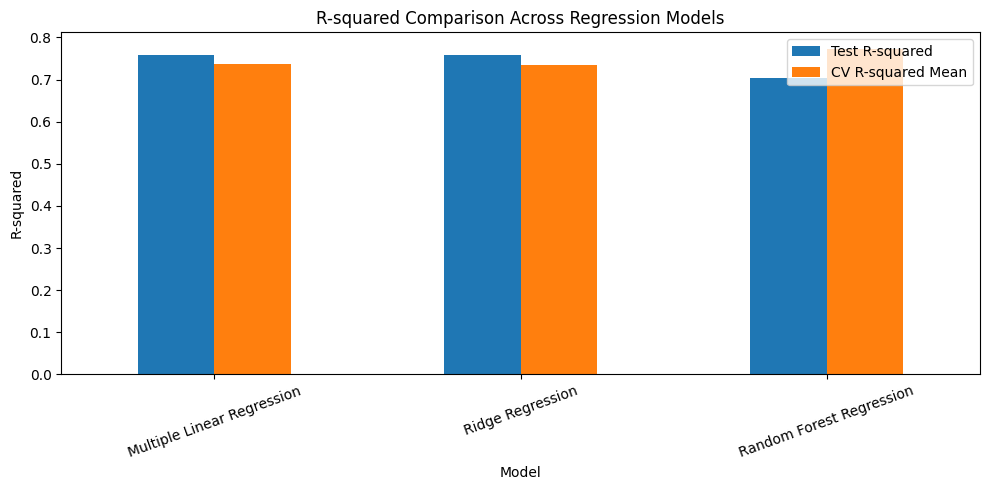

In [26]:
# Compare holdout and cross-validation R-squared values.
r2_plot = model_results.set_index("Model")[[
    "Test R-squared", "CV R-squared Mean"
]]

ax = r2_plot.plot(kind="bar", figsize=(10, 5))
ax.set_title("R-squared Comparison Across Regression Models")
ax.set_xlabel("Model")
ax.set_ylabel("R-squared")
ax.tick_params(axis="x", rotation=20)
ax.legend(loc="best")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_r2_model_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

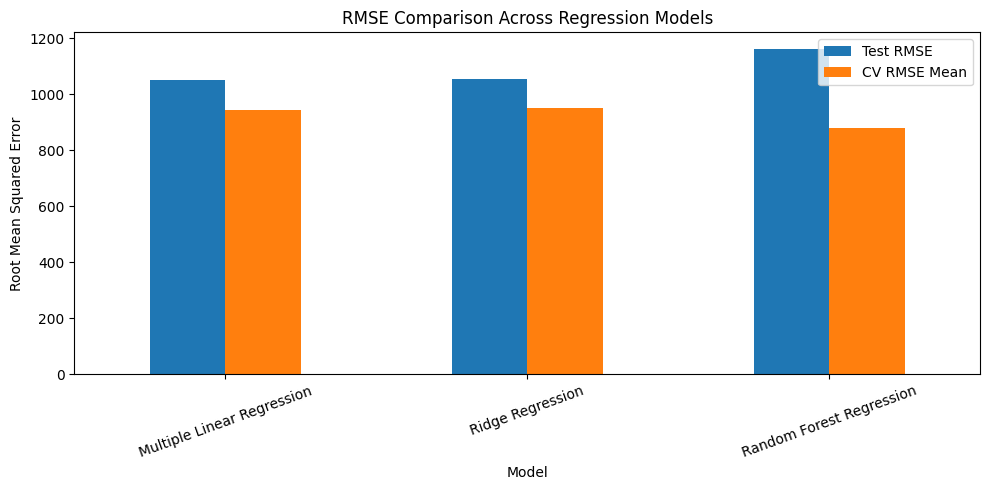

In [27]:
# Compare holdout and cross-validation RMSE values. Lower RMSE is better.
rmse_plot = model_results.set_index("Model")[[
    "Test RMSE", "CV RMSE Mean"
]]

ax = rmse_plot.plot(kind="bar", figsize=(10, 5))
ax.set_title("RMSE Comparison Across Regression Models")
ax.set_xlabel("Model")
ax.set_ylabel("Root Mean Squared Error")
ax.tick_params(axis="x", rotation=20)
ax.legend(loc="best")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_rmse_model_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

Best holdout model: Multiple Linear Regression


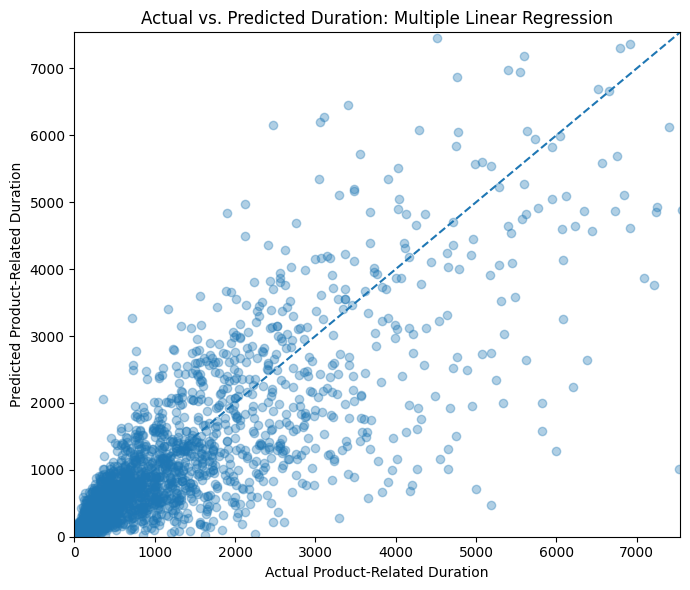

In [28]:
# Select the model with the lowest holdout RMSE for detailed diagnostics.
best_model_name = model_results.sort_values("Test RMSE").iloc[0]["Model"]
best_predictions = predictions[best_model_name]

print(f"Best holdout model: {best_model_name}")

# Limit the display range to the 99th percentile so the main pattern is visible.
plot_limit = float(np.percentile(np.concatenate([y_test.values, best_predictions]), 99))

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_predictions, alpha=0.35)
plt.plot([0, plot_limit], [0, plot_limit], linestyle="--")
plt.xlim(0, plot_limit)
plt.ylim(0, plot_limit)
plt.title(f"Actual vs. Predicted Duration: {best_model_name}")
plt.xlabel("Actual Product-Related Duration")
plt.ylabel("Predicted Product-Related Duration")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_actual_vs_predicted.png", dpi=180, bbox_inches="tight")
plt.show()

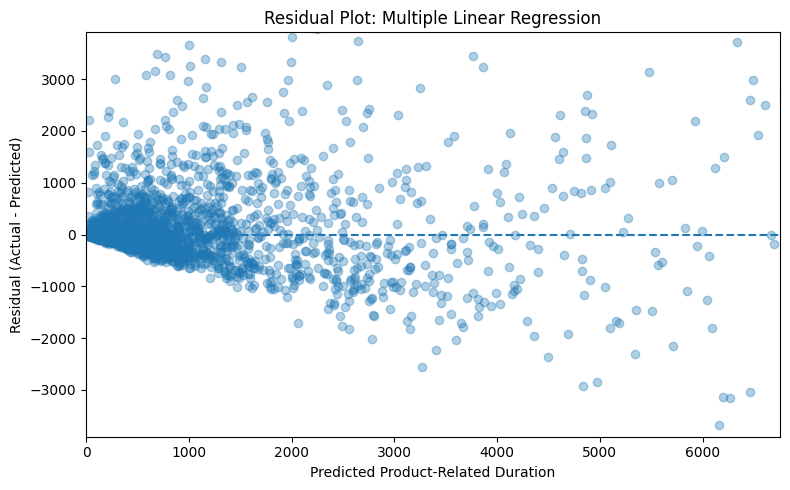

In [29]:
# Residuals reveal whether errors change systematically across predicted values.
residuals = y_test.values - best_predictions

plt.figure(figsize=(8, 5))
plt.scatter(best_predictions, residuals, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlim(0, float(np.percentile(best_predictions, 99)))
residual_limit = float(np.percentile(np.abs(residuals), 99))
plt.ylim(-residual_limit, residual_limit)
plt.title(f"Residual Plot: {best_model_name}")
plt.xlabel("Predicted Product-Related Duration")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "06_residual_plot.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. Feature Influence

The following cell extracts standardized coefficients for a linear/Ridge winner or feature importances for a Random Forest winner. Larger absolute values indicate greater influence within the selected model, but they do not prove causation.

,Feature,Coefficient
18,EngagementScore,-12.4025
5,BounceRates,-6.7710
6,ExitRates,-6.7296
26,Log_ProductRelated,2.1720
27,Log_TotalPageCount,-0.9148
19,BounceExitGap,-0.2689
32,Month_Feb,0.1058
24,Log_Administrative,-0.0883
34,Month_Jun,-0.0854
37,Month_Nov,0.0756


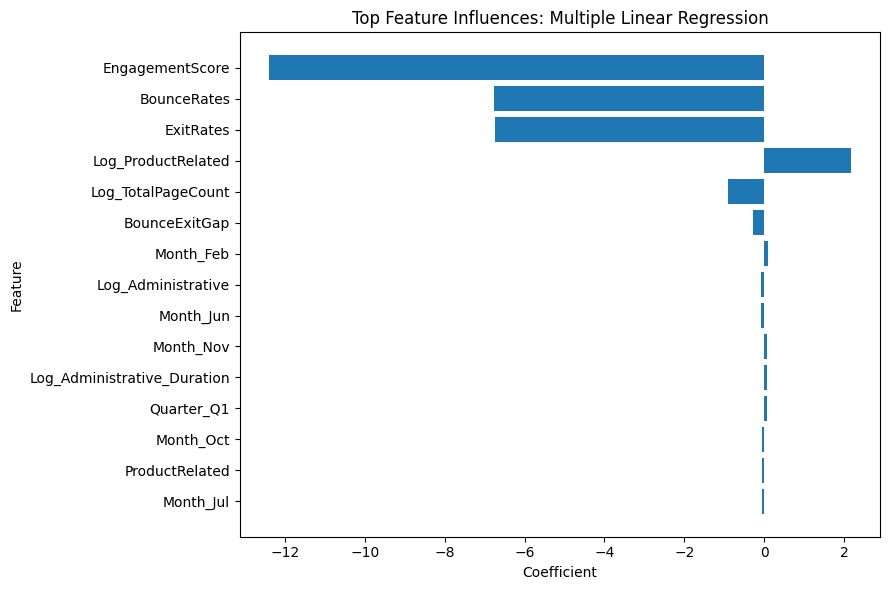

In [30]:
best_estimator = fitted_models[best_model_name]

# Access the fitted pipeline whether the estimator is target-transformed or direct.
if isinstance(best_estimator, TransformedTargetRegressor):
    fitted_pipeline = best_estimator.regressor_
else:
    fitted_pipeline = best_estimator

fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
fitted_regressor = fitted_pipeline.named_steps["model"]
feature_names = fitted_preprocessor.get_feature_names_out()

if hasattr(fitted_regressor, "coef_"):
    influence_values = np.ravel(fitted_regressor.coef_)
    influence_label = "Coefficient"
    influence_table = pd.DataFrame({
        "Feature": feature_names,
        influence_label: influence_values,
        "Absolute Influence": np.abs(influence_values),
    })
elif hasattr(fitted_regressor, "feature_importances_"):
    influence_values = fitted_regressor.feature_importances_
    influence_label = "Importance"
    influence_table = pd.DataFrame({
        "Feature": feature_names,
        influence_label: influence_values,
        "Absolute Influence": influence_values,
    })
else:
    raise AttributeError("The selected model does not expose coefficients or importances.")

# Remove technical transformer prefixes for clearer display.
influence_table["Feature"] = (
    influence_table["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

top_influences = influence_table.nlargest(15, "Absolute Influence").copy()
display(top_influences[["Feature", influence_label]].round(4))

plot_data = top_influences.sort_values("Absolute Influence", ascending=True)
plt.figure(figsize=(9, 6))
plt.barh(plot_data["Feature"], plot_data[influence_label])
plt.title(f"Top Feature Influences: {best_model_name}")
plt.xlabel(influence_label)
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "07_top_feature_influences.png", dpi=180, bbox_inches="tight")
plt.show()

## 9. Evaluation Summary and Modeling Insights

In [31]:
best_row = model_results.sort_values("Test RMSE").iloc[0]
second_row = model_results.sort_values("Test RMSE").iloc[1]

print("MODEL EVALUATION SUMMARY")
print("=" * 72)
print(f"Best model: {best_row['Model']}")
print(f"Test R-squared: {best_row['Test R-squared']:.4f}")
print(f"Test MSE:       {best_row['Test MSE']:,.2f}")
print(f"Test RMSE:      {best_row['Test RMSE']:,.2f}")
print(f"CV R-squared:   {best_row['CV R-squared Mean']:.4f} "
      f"± {best_row['CV R-squared SD']:.4f}")
print(f"CV RMSE:        {best_row['CV RMSE Mean']:,.2f} "
      f"± {best_row['CV RMSE SD']:,.2f}")
print()
print(f"Second-best holdout model: {second_row['Model']}")
print(f"RMSE difference: {second_row['Test RMSE'] - best_row['Test RMSE']:,.2f}")
print()
print("KEY INSIGHTS")
print("- Product-page count and its logarithmic representation are major predictors")
print("  of how long visitors remain on product pages.")
print("- The target is strongly right-skewed; log-target modeling reduces the impact")
print("  of unusually long sessions and improves linear-model stability.")
print("- Similar holdout and cross-validation results indicate that the selected")
print("  model generalizes reasonably well rather than merely fitting one split.")
print("- Residual spread increases for very long sessions, suggesting that extreme")
print("  engagement is harder to predict and may require richer behavioral signals.")
print("- Revenue and PageValues were excluded to avoid post-session information leakage.")

MODEL EVALUATION SUMMARY
Best model: Multiple Linear Regression
Test R-squared: 0.7590
Test MSE:       1,104,214.44
Test RMSE:      1,050.82
CV R-squared:   0.7379 ± 0.0226
CV RMSE:        944.25 ± 95.08

Second-best holdout model: Ridge Regression
RMSE difference: 2.82

KEY INSIGHTS
- Product-page count and its logarithmic representation are major predictors
  of how long visitors remain on product pages.
- The target is strongly right-skewed; log-target modeling reduces the impact
  of unusually long sessions and improves linear-model stability.
- Similar holdout and cross-validation results indicate that the selected
  model generalizes reasonably well rather than merely fitting one split.
- Residual spread increases for very long sessions, suggesting that extreme
  engagement is harder to predict and may require richer behavioral signals.
- Revenue and PageValues were excluded to avoid post-session information leakage.


## 10. Conclusion

The model with the lowest test RMSE is selected as the best-performing regression approach. Model quality is judged using both the untouched holdout set and five-fold cross-validation rather than a single training score. The analysis shows that engineered session-volume, page-mix, engagement, and log-scale features provide useful information for predicting product-page duration.

For future work, performance may improve through hyperparameter tuning, robust loss functions, gradient-boosting models, two-stage modeling for zero-duration sessions, and additional clickstream variables such as product category, device detail, referral source quality, or sequence-level navigation behavior.

# Day 3 — Classification, Clustering, and Association Rule Mining

Complete executed Day 3 workflow: classification, decision-tree tuning, ROC and confusion-matrix evaluation, K-Means segmentation, PCA visualization, cluster profiling, Apriori rules, and practical applications.

In [32]:
# Core libraries
from pathlib import Path
from itertools import combinations
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn: preprocessing, supervised learning, evaluation, and clustering
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    silhouette_score,
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

RANDOM_STATE = 42
DATA_PATH = Path('online_shoppers_intention.csv')
FIGURE_DIR = Path('figures')
OUTPUT_DIR = Path('outputs')
FIGURE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print('Libraries imported and output folders prepared.')

Libraries imported and output folders prepared.


## 1. Load, inspect, and clean the dataset

The original file contains 12,330 sessions and 18 columns. Cleaning removes exact duplicate sessions, standardizes categorical labels, validates logical ranges, and preserves legitimate long browsing sessions rather than treating all large values as errors.

In [33]:
# Load the dataset from the repository root.
df_raw = pd.read_csv(DATA_PATH)

print(f'Raw shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
display(df_raw.head())

inspection = pd.DataFrame({
    'Data Type': df_raw.dtypes.astype(str),
    'Missing Values': df_raw.isna().sum(),
    'Unique Values': df_raw.nunique(dropna=False),
})
display(inspection)
print(f'Exact duplicate rows: {df_raw.duplicated().sum():,}')

Raw shape: 12,330 rows × 18 columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0000,0,0.0000,2,64.0000,0.0000,0.1000,0.0000,0.0000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0000,0,0.0000,2,2.6667,0.0500,0.1400,0.0000,0.0000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0000,0,0.0000,10,627.5000,0.0200,0.0500,0.0000,0.0000,Feb,3,3,1,4,Returning_Visitor,True,False


,Data Type,Missing Values,Unique Values
Administrative,int64,0,27
Administrative_Duration,float64,0,3335
Informational,int64,0,17
Informational_Duration,float64,0,1258
ProductRelated,int64,0,311
ProductRelated_Duration,float64,0,9551
BounceRates,float64,0,1872
ExitRates,float64,0,4777
PageValues,float64,0,2704
SpecialDay,float64,0,6


Exact duplicate rows: 125


In [34]:
# Create a clean working copy.
df = df_raw.copy()

# Standardize text-based categories.
for column in ['Month', 'VisitorType']:
    df[column] = df[column].astype(str).str.strip()
df['Month'] = df['Month'].str[:3].str.title()

# Normalize Boolean fields in case a CSV reader loads them as strings.
def to_boolean(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    return series.astype(str).str.strip().str.lower().map({'true': True, 'false': False})

df['Weekend'] = to_boolean(df['Weekend'])
df['Revenue'] = to_boolean(df['Revenue'])

# Correct impossible negative values and constrain proportion fields to [0, 1].
nonnegative_columns = [
    'Administrative', 'Administrative_Duration', 'Informational',
    'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]
for column in nonnegative_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce').clip(lower=0)
for column in ['BounceRates', 'ExitRates', 'SpecialDay']:
    df[column] = df[column].clip(0, 1)

# Remove exact duplicates and reset the row index.
df = df.drop_duplicates().reset_index(drop=True)

print(f'Cleaned shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Rows removed: {len(df_raw) - len(df):,}')
print(f'Remaining missing values: {int(df.isna().sum().sum()):,}')
print('\nClass distribution:')
display(
    df['Revenue'].value_counts().rename_axis('Revenue').to_frame('Sessions')
      .assign(Percentage=lambda x: 100 * x['Sessions'] / len(df))
)

Cleaned shape: 12,205 rows × 18 columns
Rows removed: 125
Remaining missing values: 0

Class distribution:


,Sessions,Percentage
Revenue,,
False,10297,84.3671
True,1908,15.6329


### Feature engineering

The added features summarize browsing volume and quality without using the target:

- `TotalPageCount` and `TotalDuration` measure overall activity.
- `AvgProductTime` measures product-page depth while safely handling zero-page sessions.
- `EngagementScore` is high when both bounce and exit rates are low.
- `ExitBounceGap` captures the difference between exit and bounce behaviour.

In [35]:
# Leakage-safe behavioural feature engineering.
df['TotalPageCount'] = (
    df['Administrative'] + df['Informational'] + df['ProductRelated']
)
df['TotalDuration'] = (
    df['Administrative_Duration']
    + df['Informational_Duration']
    + df['ProductRelated_Duration']
)
df['AvgProductTime'] = (
    df['ProductRelated_Duration']
    / df['ProductRelated'].replace(0, np.nan)
).fillna(0)
df['EngagementScore'] = (1 - df['BounceRates']) * (1 - df['ExitRates'])
df['ExitBounceGap'] = df['ExitRates'] - df['BounceRates']

engineered_columns = [
    'TotalPageCount', 'TotalDuration', 'AvgProductTime',
    'EngagementScore', 'ExitBounceGap'
]
display(df[engineered_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
TotalPageCount,"12,205.0000",34.8932,46.6273,0.0000,9.0000,20.0000,42.0000,746.0000
TotalDuration,"12,205.0000","1,323.4542","2,043.8716",0.0000,231.6667,690.9583,"1,643.9583","69,921.6472"
AvgProductTime,"12,205.0000",38.0191,44.8335,0.0000,17.9792,29.1461,45.2917,"1,411.0000"
EngagementScore,"12,205.0000",0.9409,0.0809,0.6400,0.9381,0.9689,0.9843,1.0000
ExitBounceGap,"12,205.0000",0.0211,0.0202,-0.0656,0.0083,0.0160,0.0275,0.2000


## 2. Classification modelling

Two different tree-based classifiers are developed:

1. **Decision Tree:** interpretable nonlinear baseline.
2. **Random Forest:** ensemble model designed to improve stability and generalization.

Because purchases are the minority class, both models use class weighting. The split is stratified so the purchase rate remains consistent in training and test data. Technical category codes—operating system, browser, region, and traffic type—are treated as categorical rather than continuous measurements.

In [36]:
TARGET = 'Revenue'
CATEGORICAL_COLUMNS = [
    'Month', 'OperatingSystems', 'Browser', 'Region',
    'TrafficType', 'VisitorType', 'Weekend'
]

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int)

# Treat integer identifiers as category labels.
for column in CATEGORICAL_COLUMNS:
    X[column] = X[column].astype(str)

NUMERICAL_COLUMNS = [column for column in X.columns if column not in CATEGORICAL_COLUMNS]

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, NUMERICAL_COLUMNS),
    ('categorical', categorical_pipeline, CATEGORICAL_COLUMNS),
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f'Training sessions: {len(X_train):,}')
print(f'Test sessions: {len(X_test):,}')
print(f'Training purchase rate: {y_train.mean():.3%}')
print(f'Test purchase rate: {y_test.mean():.3%}')

Training sessions: 9,764
Test sessions: 2,441
Training purchase rate: 15.629%
Test purchase rate: 15.649%


In [37]:
# Model 1: balanced Decision Tree.
decision_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=7,
        min_samples_leaf=15,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

# Model 2: balanced Random Forest baseline.
random_forest = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

print('Classification pipelines created.')

Classification pipelines created.


### Hyperparameter tuning

The Decision Tree is tuned with **GridSearchCV** using three-fold stratified cross-validation. The search optimizes **F1 score**, not accuracy, because accuracy alone can appear high when the majority class dominates.

Tuned parameters:

- `criterion`: compares Gini impurity and entropy.
- `max_depth`: controls tree complexity.
- `min_samples_split`: sets the minimum observations required to split a node.
- `min_samples_leaf`: prevents leaves from being based on too few sessions.

In [38]:
# Cross-validated hyperparameter tuning for the Decision Tree.
dt_search_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

parameter_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [4, 6, 8, 10],
    'model__min_samples_split': [2, 20],
    'model__min_samples_leaf': [10, 30],
}

cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

dt_grid_search = GridSearchCV(
    estimator=dt_search_pipeline,
    param_grid=parameter_grid,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=1,
    return_train_score=True,
)

dt_grid_search.fit(X_train, y_train)
tuned_decision_tree = dt_grid_search.best_estimator_

print(f'Best cross-validated F1: {dt_grid_search.best_score_:.4f}')
print('Best parameters:')
print(json.dumps(dt_grid_search.best_params_, indent=2))

with open(OUTPUT_DIR / 'best_hyperparameters.json', 'w', encoding='utf-8') as file:
    json.dump(dt_grid_search.best_params_, file, indent=2)

Best cross-validated F1: 0.6358
Best parameters:
{
  "model__criterion": "entropy",
  "model__max_depth": 6,
  "model__min_samples_leaf": 30,
  "model__min_samples_split": 2
}


### Classification evaluation

Every model is evaluated on the untouched test set. The positive-class F1 score is emphasized because it balances precision and recall for purchase sessions.

In [39]:
models = {
    'Decision Tree': decision_tree,
    'Random Forest': random_forest,
    'Tuned Decision Tree': tuned_decision_tree,
}

model_predictions = {}
model_probabilities = {}
metric_rows = []
report_frames = []

for model_name, model in models.items():
    # GridSearchCV already fitted the tuned estimator; refitting is harmless and
    # keeps this evaluation loop consistent for every model.
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    model_predictions[model_name] = predictions
    model_probabilities[model_name] = probabilities

    metric_rows.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'F1 Score': f1_score(y_test, predictions),
        'ROC-AUC': roc_auc_score(y_test, probabilities),
    })

    report = pd.DataFrame(
        classification_report(
            y_test,
            predictions,
            target_names=['No Purchase', 'Purchase'],
            output_dict=True,
            zero_division=0,
        )
    ).T.reset_index().rename(columns={'index': 'Class'})
    report.insert(0, 'Model', model_name)
    report_frames.append(report)

classification_metrics = pd.DataFrame(metric_rows).sort_values(
    'F1 Score', ascending=False
).reset_index(drop=True)
classification_reports = pd.concat(report_frames, ignore_index=True)

classification_metrics.to_csv(OUTPUT_DIR / 'classification_metrics.csv', index=False)
classification_reports.to_csv(OUTPUT_DIR / 'classification_reports.csv', index=False)

display(classification_metrics)

,Model,Accuracy,F1 Score,ROC-AUC
0,Decision Tree,0.8472,0.6213,0.9072
1,Tuned Decision Tree,0.8275,0.6148,0.9270
2,Random Forest,0.8947,0.5965,0.9241


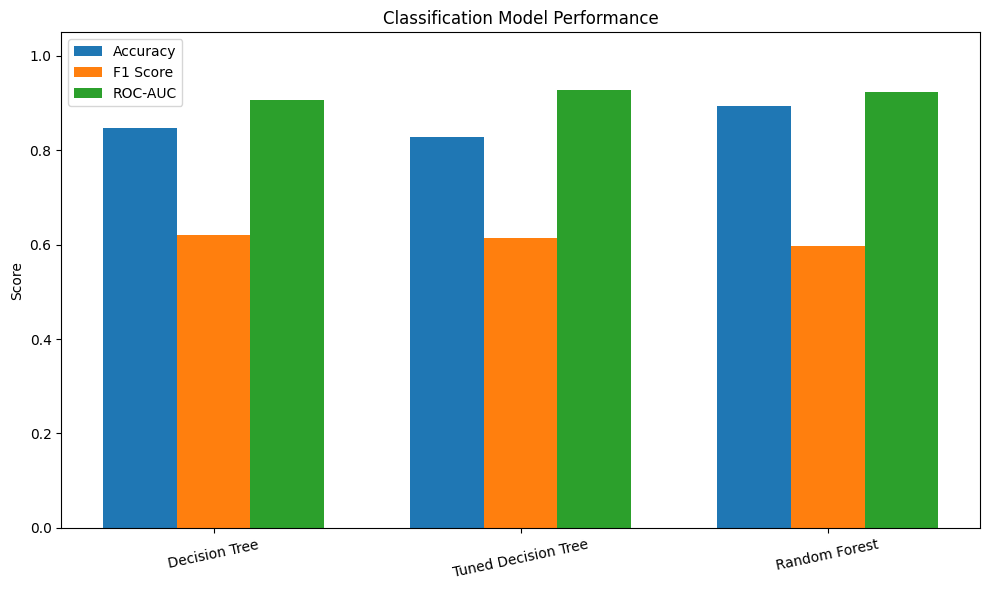

In [40]:
# Model-performance comparison.
metric_names = ['Accuracy', 'F1 Score', 'ROC-AUC']
x = np.arange(len(classification_metrics))
width = 0.24

plt.figure(figsize=(10, 6))
for offset, metric in enumerate(metric_names):
    plt.bar(
        x + (offset - 1) * width,
        classification_metrics[metric],
        width,
        label=metric,
    )
plt.xticks(x, classification_metrics['Model'], rotation=12)
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.title('Classification Model Performance')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / '01_classification_model_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

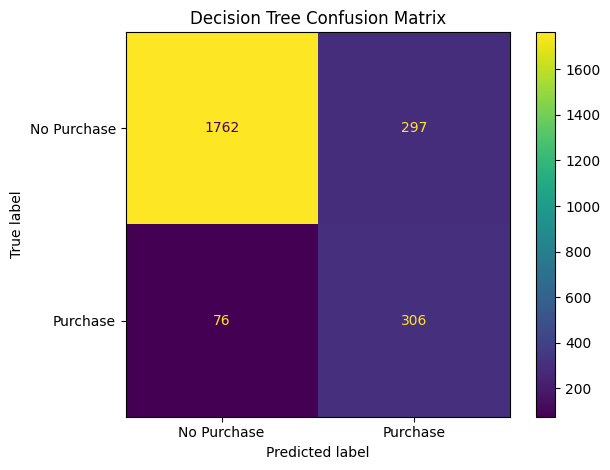

In [41]:
# Confusion matrix: Decision Tree.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    model_predictions['Decision Tree'],
    display_labels=['No Purchase', 'Purchase'],
    values_format='d',
)
plt.title('Decision Tree Confusion Matrix')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '02_decision_tree_confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()

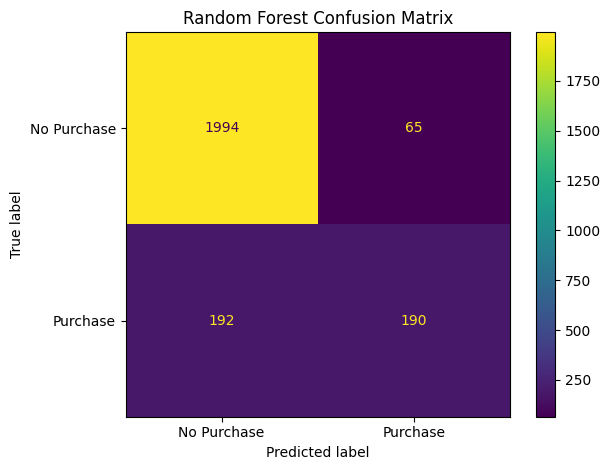

In [42]:
# Confusion matrix: Random Forest baseline.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    model_predictions['Random Forest'],
    display_labels=['No Purchase', 'Purchase'],
    values_format='d',
)
plt.title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '03_random_forest_confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()

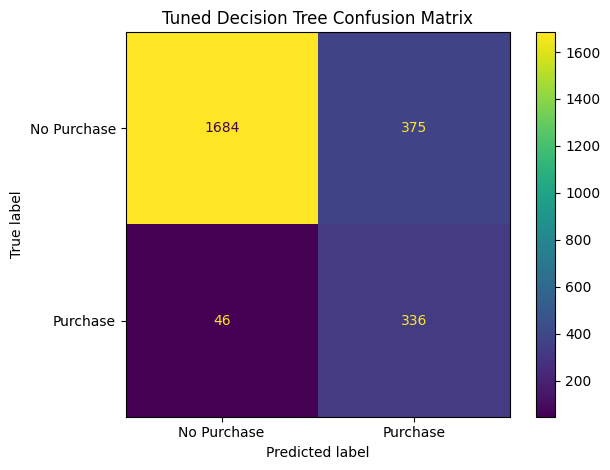

In [43]:
# Confusion matrix: tuned Decision Tree.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    model_predictions['Tuned Decision Tree'],
    display_labels=['No Purchase', 'Purchase'],
    values_format='d',
)
plt.title('Tuned Decision Tree Confusion Matrix')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '04_tuned_decision_tree_confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()

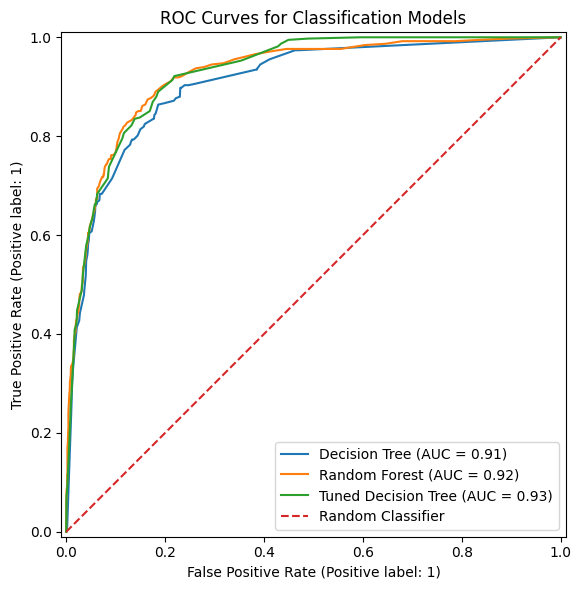

In [44]:
# ROC curves for all classification models.
plt.figure(figsize=(8, 6))
axis = plt.gca()
for model_name, probabilities in model_probabilities.items():
    RocCurveDisplay.from_predictions(
        y_test,
        probabilities,
        name=model_name,
        ax=axis,
    )
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.title('ROC Curves for Classification Models')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / '05_classification_roc_curves.png', dpi=180, bbox_inches='tight')
plt.show()

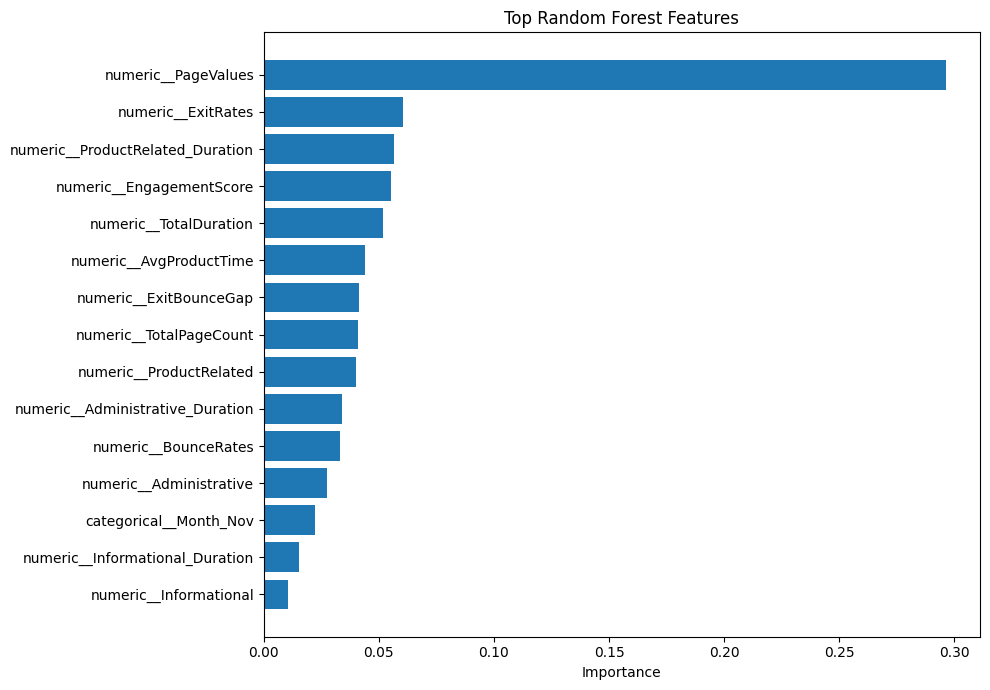

,Feature,Importance
8,numeric__PageValues,0.2963
7,numeric__ExitRates,0.0604
5,numeric__ProductRelated_Duration,0.0565
13,numeric__EngagementScore,0.0552
11,numeric__TotalDuration,0.0516
12,numeric__AvgProductTime,0.0439
14,numeric__ExitBounceGap,0.0415
10,numeric__TotalPageCount,0.0410
4,numeric__ProductRelated,0.0401
1,numeric__Administrative_Duration,0.0341


In [45]:
# Inspect the fitted Random Forest's most influential encoded features.
best_preprocessor = random_forest.named_steps['preprocessor']
best_classifier = random_forest.named_steps['model']
feature_names = best_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_classifier.feature_importances_,
}).sort_values('Importance', ascending=False)
feature_importance.to_csv(OUTPUT_DIR / 'random_forest_feature_importance.csv', index=False)

top_features = feature_importance.head(15).sort_values('Importance')
plt.figure(figsize=(10, 7))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.title('Top Random Forest Features')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '06_random_forest_feature_importance.png', dpi=180, bbox_inches='tight')
plt.show()

display(feature_importance.head(15))

In [46]:
# Print an evidence-based classification summary.
best_row = classification_metrics.iloc[0]
best_name = best_row['Model']
best_confusion = confusion_matrix(y_test, model_predictions[best_name])
tn, fp, fn, tp = best_confusion.ravel()

print(f'Best F1 model: {best_name}')
print(f"Accuracy: {best_row['Accuracy']:.4f}")
print(f"F1 score: {best_row['F1 Score']:.4f}")
print(f"ROC-AUC: {best_row['ROC-AUC']:.4f}")
print(f'True negatives: {tn:,}; false positives: {fp:,}; false negatives: {fn:,}; true positives: {tp:,}')
print('\nInterpretation: the tuned tree balances purchase detection and overall discrimination, while the Random Forest provides a strong ensemble benchmark.')

Best F1 model: Decision Tree
Accuracy: 0.8472
F1 score: 0.6213
ROC-AUC: 0.9072
True negatives: 1,762; false positives: 297; false negatives: 76; true positives: 306

Interpretation: the tuned tree balances purchase detection and overall discrimination, while the Random Forest provides a strong ensemble benchmark.


## 3. K-Means clustering

Clustering is performed without using `Revenue`. The purpose is to discover naturally occurring session-behaviour groups. Count, duration, and page-value fields are log-transformed to reduce extreme right skew, then all clustering features are standardized.

The number of clusters is selected by comparing silhouette scores for `k = 2` through `k = 6`.

In [47]:
CLUSTER_FEATURES = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
]
LOG_CLUSTER_FEATURES = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration', 'PageValues',
]

cluster_data = df[CLUSTER_FEATURES].copy()
for column in LOG_CLUSTER_FEATURES:
    cluster_data[column] = np.log1p(cluster_data[column])

cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_data)

silhouette_rows = []
for k in range(2, 7):
    candidate_model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE,
    )
    candidate_labels = candidate_model.fit_predict(cluster_scaled)
    score = silhouette_score(
        cluster_scaled,
        candidate_labels,
        sample_size=min(4000, len(df)),
        random_state=RANDOM_STATE,
    )
    silhouette_rows.append({'Clusters': k, 'Silhouette Score': score})

silhouette_results = pd.DataFrame(silhouette_rows)
silhouette_results.to_csv(OUTPUT_DIR / 'silhouette_scores.csv', index=False)
display(silhouette_results)

,Clusters,Silhouette Score
0,2,0.2647
1,3,0.3634
2,4,0.3205
3,5,0.3462
4,6,0.3527


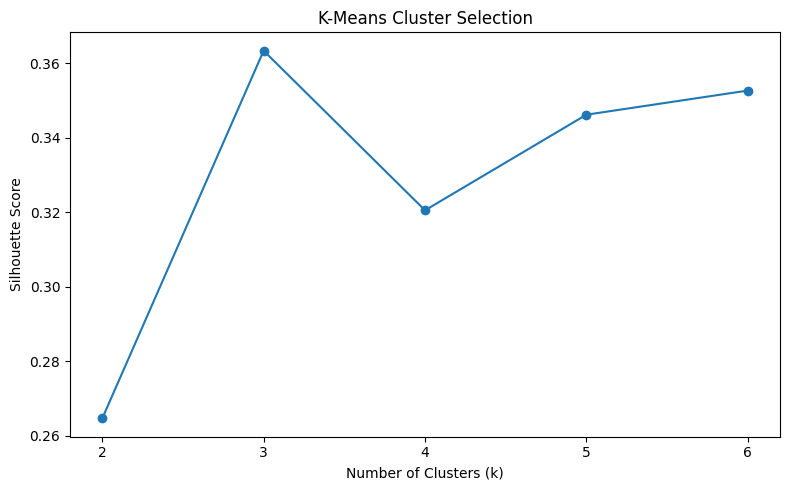

In [48]:
# Visualize the silhouette comparison.
plt.figure(figsize=(8, 5))
plt.plot(
    silhouette_results['Clusters'],
    silhouette_results['Silhouette Score'],
    marker='o',
)
plt.xticks(silhouette_results['Clusters'])
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('K-Means Cluster Selection')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '07_kmeans_silhouette_scores.png', dpi=180, bbox_inches='tight')
plt.show()

In [49]:
# Select the k with the highest silhouette score and fit the final model.
best_k = int(
    silhouette_results.loc[
        silhouette_results['Silhouette Score'].idxmax(), 'Clusters'
    ]
)

kmeans = KMeans(
    n_clusters=best_k,
    n_init=30,
    random_state=RANDOM_STATE,
)
cluster_ids = kmeans.fit_predict(cluster_scaled)
df['Cluster_ID'] = cluster_ids

# Assign readable names based on objective profile characteristics.
raw_profile = df.groupby('Cluster_ID')[CLUSTER_FEATURES].mean()
brief_cluster = raw_profile['BounceRates'].idxmax()
engaged_cluster = raw_profile['ProductRelated_Duration'].idxmax()
remaining_clusters = [
    cluster_id for cluster_id in raw_profile.index
    if cluster_id not in {brief_cluster, engaged_cluster}
]

cluster_name_map = {
    int(brief_cluster): 'Brief High-Bounce Sessions',
    int(engaged_cluster): 'Highly Engaged Researchers',
}
for cluster_id in remaining_clusters:
    cluster_name_map[int(cluster_id)] = 'Typical Product Browsers'

df['Cluster'] = df['Cluster_ID'].map(cluster_name_map)

print(f'Selected number of clusters: {best_k}')
print('Cluster-name mapping:', cluster_name_map)

Selected number of clusters: 3
Cluster-name mapping: {2: 'Brief High-Bounce Sessions', 0: 'Highly Engaged Researchers', 1: 'Typical Product Browsers'}


In [50]:
# Profile each cluster. Revenue is shown only after clustering as an external
# business outcome; it was not used to form the clusters.
cluster_profiles = df.groupby('Cluster').agg(
    Sessions=('Revenue', 'size'),
    Purchase_Rate=('Revenue', 'mean'),
    Administrative_Pages=('Administrative', 'mean'),
    Informational_Pages=('Informational', 'mean'),
    Product_Pages=('ProductRelated', 'mean'),
    Product_Duration=('ProductRelated_Duration', 'mean'),
    Bounce_Rate=('BounceRates', 'mean'),
    Exit_Rate=('ExitRates', 'mean'),
    Page_Value=('PageValues', 'mean'),
).sort_values('Product_Duration', ascending=False)

cluster_profiles.to_csv(OUTPUT_DIR / 'cluster_profiles.csv')
display(cluster_profiles)

,Sessions,Purchase_Rate,Administrative_Pages,Informational_Pages,Product_Pages,Product_Duration,Bounce_Rate,Exit_Rate,Page_Value
Cluster,,,,,,,,,
Highly Engaged Researchers,2310,0.2455,5.1645,2.5264,66.5801,"2,632.6841",0.0073,0.0217,8.6254
Typical Product Browsers,9021,0.1482,1.8382,0.0394,26.0653,955.1768,0.0097,0.0330,5.8408
Brief High-Bounce Sessions,874,0.0046,0.0389,0.0206,2.4966,37.8386,0.1654,0.1810,0.0000


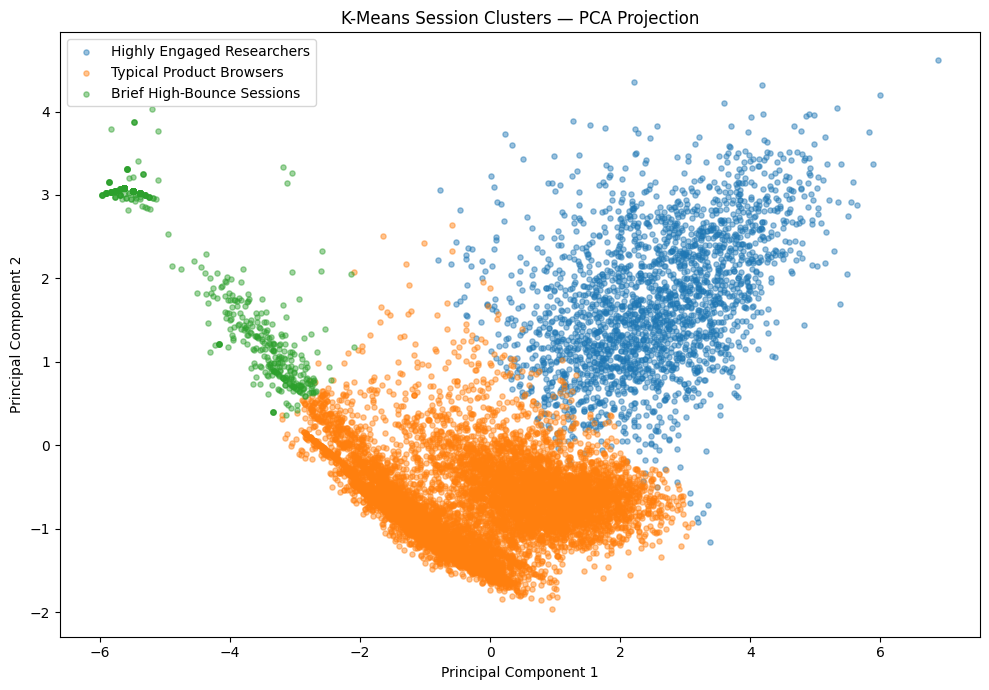

PCA variance represented: 60.53%


In [51]:
# Two-dimensional PCA projection for visualization only.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
cluster_pca = pca.fit_transform(cluster_scaled)

pca_frame = pd.DataFrame({
    'PC1': cluster_pca[:, 0],
    'PC2': cluster_pca[:, 1],
    'Cluster': df['Cluster'],
})

plt.figure(figsize=(10, 7))
for cluster_name in cluster_profiles.index:
    group = pca_frame[pca_frame['Cluster'] == cluster_name]
    plt.scatter(
        group['PC1'],
        group['PC2'],
        s=14,
        alpha=0.45,
        label=cluster_name,
    )
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Session Clusters — PCA Projection')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / '08_kmeans_pca_clusters.png', dpi=180, bbox_inches='tight')
plt.show()

print(f'PCA variance represented: {pca.explained_variance_ratio_.sum():.2%}')

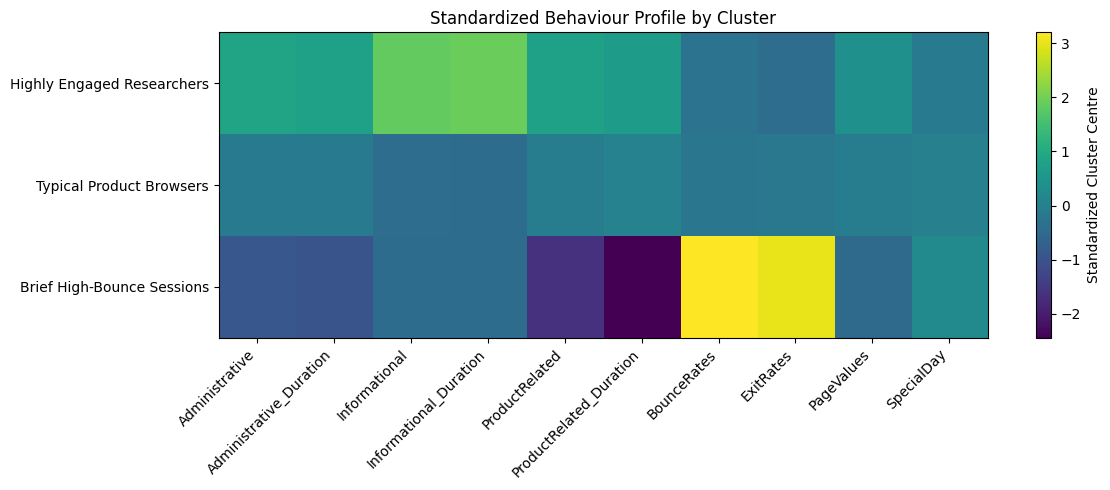

In [52]:
# Standardized cluster-centre profile heatmap.
centre_frame = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=CLUSTER_FEATURES,
    index=[cluster_name_map[int(i)] for i in range(best_k)],
)
centre_frame = centre_frame.loc[cluster_profiles.index]

plt.figure(figsize=(12, 5))
image = plt.imshow(centre_frame, aspect='auto')
plt.colorbar(image, label='Standardized Cluster Centre')
plt.xticks(range(len(CLUSTER_FEATURES)), CLUSTER_FEATURES, rotation=45, ha='right')
plt.yticks(range(len(centre_frame)), centre_frame.index)
plt.title('Standardized Behaviour Profile by Cluster')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '09_cluster_profile_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()

In [53]:
# Generate a concise interpretation from the measured cluster profiles.
for cluster_name, row in cluster_profiles.iterrows():
    print(
        f"{cluster_name}: {int(row['Sessions']):,} sessions, "
        f"{row['Purchase_Rate']:.1%} purchase rate, "
        f"{row['Product_Pages']:.1f} average product pages, "
        f"{row['Bounce_Rate']:.3f} average bounce rate."
    )

Highly Engaged Researchers: 2,310 sessions, 24.5% purchase rate, 66.6 average product pages, 0.007 average bounce rate.
Typical Product Browsers: 9,021 sessions, 14.8% purchase rate, 26.1 average product pages, 0.010 average bounce rate.
Brief High-Bounce Sessions: 874 sessions, 0.5% purchase rate, 2.5 average product pages, 0.165 average bounce rate.


## 4. Apriori association rule mining

The source data contains one row per session rather than individual products in a basket. Therefore, transactions are constructed from meaningful **session-level Boolean conditions**, such as positive page value, high product engagement, low bounce rate, visitor type, weekend activity, month, cluster membership, and purchase outcome.

A compact Apriori implementation is included below so the notebook has no dependency on `mlxtend`. It mines frequent itemsets up to length three and produces rules with support, confidence, lift, leverage, and conviction.

In [54]:
# Convert continuous and categorical session characteristics into Boolean items.
positive_page_values = df.loc[df['PageValues'] > 0, 'PageValues']

transactions = pd.DataFrame(index=df.index)
transactions['Revenue_Yes'] = df['Revenue']
transactions['Revenue_No'] = ~df['Revenue']
transactions['PageValue_Positive'] = df['PageValues'] > 0
transactions['PageValue_High'] = (
    df['PageValues'] >= positive_page_values.quantile(0.75)
)
transactions['ProductPages_High'] = (
    df['ProductRelated'] >= df['ProductRelated'].quantile(0.75)
)
transactions['ProductDuration_High'] = (
    df['ProductRelated_Duration'] >= df['ProductRelated_Duration'].quantile(0.75)
)
transactions['Bounce_Low'] = (
    df['BounceRates'] <= df['BounceRates'].quantile(0.25)
)
transactions['Bounce_High'] = (
    df['BounceRates'] >= df['BounceRates'].quantile(0.75)
)
transactions['Exit_Low'] = (
    df['ExitRates'] <= df['ExitRates'].quantile(0.25)
)
transactions['Exit_High'] = (
    df['ExitRates'] >= df['ExitRates'].quantile(0.75)
)
transactions['Administrative_Visited'] = df['Administrative'] > 0
transactions['Informational_Visited'] = df['Informational'] > 0
transactions['New_Visitor'] = df['VisitorType'].eq('New_Visitor')
transactions['Returning_Visitor'] = df['VisitorType'].eq('Returning_Visitor')
transactions['Weekend'] = df['Weekend']
transactions['Month_Nov'] = df['Month'].eq('Nov')
transactions['SpecialDay_Near'] = df['SpecialDay'] > 0

# Include discovered clusters as transaction items.
for cluster_name in cluster_profiles.index:
    item_name = 'Cluster_' + cluster_name.replace(' ', '_').replace('-', '_')
    transactions[item_name] = df['Cluster'].eq(cluster_name)

item_support = transactions.mean().sort_values(ascending=False).to_frame('Support')
display(item_support)

,Support
Returning_Visitor,0.8546
Revenue_No,0.8437
Cluster_Typical_Product_Browsers,0.7391
Administrative_Visited,0.5376
Bounce_Low,0.4521
ProductPages_High,0.2545
Bounce_High,0.2506
ProductDuration_High,0.2501
Exit_High,0.2501
Exit_Low,0.2501


In [55]:
def apriori_frequent_itemsets(
    binary_data: pd.DataFrame,
    min_support: float = 0.03,
    max_length: int = 3,
):
    """Mine frequent itemsets with Apriori candidate generation and pruning."""
    support_lookup = {}
    current_level = []

    # Frequent one-item sets.
    for column in binary_data.columns:
        itemset = frozenset([column])
        support = float(binary_data[column].mean())
        if support >= min_support:
            support_lookup[itemset] = support
            current_level.append(itemset)

    itemset_length = 2
    while current_level and itemset_length <= max_length:
        candidates = set()

        # Join frequent (k-1)-itemsets to create k-item candidates.
        for left, right in combinations(current_level, 2):
            candidate = left | right
            if len(candidate) != itemset_length:
                continue

            # Apriori pruning: every (k-1) subset must already be frequent.
            all_subsets_frequent = all(
                frozenset(subset) in support_lookup
                for subset in combinations(candidate, itemset_length - 1)
            )
            if all_subsets_frequent:
                candidates.add(candidate)

        next_level = []
        for candidate in candidates:
            support = float(binary_data[list(candidate)].all(axis=1).mean())
            if support >= min_support:
                support_lookup[candidate] = support
                next_level.append(candidate)

        current_level = next_level
        itemset_length += 1

    frequent_itemsets = pd.DataFrame([
        {
            'Itemset': tuple(sorted(itemset)),
            'Length': len(itemset),
            'Support': support,
        }
        for itemset, support in support_lookup.items()
    ]).sort_values(['Length', 'Support'], ascending=[True, False])

    return frequent_itemsets.reset_index(drop=True), support_lookup


def generate_association_rules(
    support_lookup: dict,
    min_confidence: float = 0.55,
    min_lift: float = 1.10,
):
    """Create association rules and standard rule-quality statistics."""
    rows = []

    for itemset, itemset_support in support_lookup.items():
        if len(itemset) < 2:
            continue

        items = list(itemset)
        for antecedent_size in range(1, len(items)):
            for antecedent_tuple in combinations(items, antecedent_size):
                antecedent = frozenset(antecedent_tuple)
                consequent = itemset - antecedent

                antecedent_support = support_lookup.get(antecedent)
                consequent_support = support_lookup.get(consequent)
                if antecedent_support is None or consequent_support is None:
                    continue

                confidence = itemset_support / antecedent_support
                lift = confidence / consequent_support

                if confidence < min_confidence or lift < min_lift:
                    continue

                leverage = itemset_support - antecedent_support * consequent_support
                conviction = (
                    (1 - consequent_support) / (1 - confidence)
                    if confidence < 1 else np.inf
                )

                rows.append({
                    'Antecedent': ' AND '.join(sorted(antecedent)),
                    'Consequent': ' AND '.join(sorted(consequent)),
                    'Support': itemset_support,
                    'Confidence': confidence,
                    'Lift': lift,
                    'Leverage': leverage,
                    'Conviction': conviction,
                })

    if not rows:
        return pd.DataFrame(columns=[
            'Antecedent', 'Consequent', 'Support', 'Confidence',
            'Lift', 'Leverage', 'Conviction'
        ])

    return pd.DataFrame(rows).sort_values(
        ['Lift', 'Confidence', 'Support'],
        ascending=False,
    ).reset_index(drop=True)

In [56]:
MIN_SUPPORT = 0.03
MIN_CONFIDENCE = 0.55
MIN_LIFT = 1.10

frequent_itemsets, support_lookup = apriori_frequent_itemsets(
    transactions,
    min_support=MIN_SUPPORT,
    max_length=3,
)
association_rules = generate_association_rules(
    support_lookup,
    min_confidence=MIN_CONFIDENCE,
    min_lift=MIN_LIFT,
)

purchase_rules = association_rules[
    association_rules['Consequent'].eq('Revenue_Yes')
].copy()

frequent_itemsets.to_csv(OUTPUT_DIR / 'frequent_itemsets.csv', index=False)
association_rules.to_csv(OUTPUT_DIR / 'association_rules.csv', index=False)
purchase_rules.to_csv(OUTPUT_DIR / 'purchase_association_rules.csv', index=False)

print(f'Frequent itemsets found: {len(frequent_itemsets):,}')
print(f'Association rules found: {len(association_rules):,}')
print(f'Rules predicting purchase: {len(purchase_rules):,}')
display(purchase_rules.head(15))

Frequent itemsets found: 484
Association rules found: 371
Rules predicting purchase: 10


,Antecedent,Consequent,Support,Confidence,Lift,Leverage,Conviction
6,Bounce_Low AND PageValue_High,Revenue_Yes,0.0349,0.8765,5.6070,0.0287,6.8337
8,Cluster_Typical_Product_Browsers AND PageValue...,Revenue_Yes,0.0352,0.8190,5.2392,0.0285,4.6624
10,PageValue_High,Revenue_Yes,0.0437,0.7804,4.9919,0.0349,3.8415
11,PageValue_High AND PageValue_Positive,Revenue_Yes,0.0437,0.7804,4.9919,0.0349,3.8415
21,Bounce_Low AND PageValue_Positive,Revenue_Yes,0.0714,0.7315,4.6795,0.0562,3.1427
50,Exit_Low AND PageValue_Positive,Revenue_Yes,0.0604,0.6724,4.3015,0.0463,2.5757
51,Month_Nov AND PageValue_Positive,Revenue_Yes,0.0422,0.6594,4.2181,0.0322,2.4771
55,Cluster_Typical_Product_Browsers AND PageValue...,Revenue_Yes,0.0874,0.6310,4.0363,0.0658,2.2863
69,PageValue_Positive AND Weekend,Revenue_Yes,0.0326,0.5827,3.7275,0.0239,2.0218
74,PageValue_Positive,Revenue_Yes,0.1260,0.5634,3.6037,0.0910,1.9322


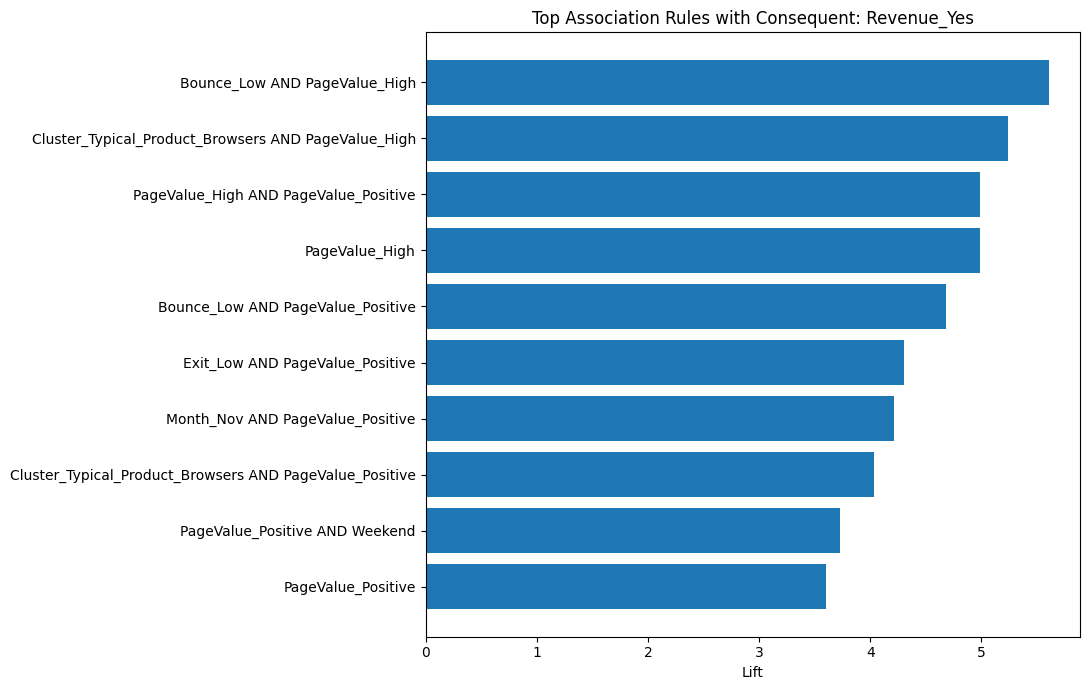

In [57]:
# Visualize the strongest purchase rules by lift.
top_purchase_rules = purchase_rules.head(10).sort_values('Lift')

plt.figure(figsize=(11, 7))
plt.barh(top_purchase_rules['Antecedent'], top_purchase_rules['Lift'])
plt.xlabel('Lift')
plt.title('Top Association Rules with Consequent: Revenue_Yes')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '10_top_purchase_association_rules.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. Practical application of discovered patterns

The results support several real-world e-commerce actions:

- **Purchase-intent scoring:** Use the best-performing classifier to prioritize sessions for personalized offers, live assistance, or remarketing. The operating threshold should be selected according to the cost of missing a likely buyer versus contacting a non-buyer.
- **High-engagement sessions:** Visitors who research many product and information pages are strong candidates for comparison tools, product recommendations, saved carts, and detailed content.
- **Typical product browsers:** This largest group can be guided with clearer calls to action, social proof, shipping information, and personalized recommendations.
- **Brief high-bounce sessions:** Improve landing-page relevance, site speed, mobile usability, and navigation for sessions that leave quickly and rarely purchase.
- **Association rules:** Rules connecting positive/high page value, low bounce/exit behaviour, November traffic, and purchase can guide campaign timing and trigger-based personalization.

### Important limitation

`PageValues` is extremely predictive, but it may be computed late in the session and may not be available at the earliest intervention point. A production implementation should validate when the feature becomes available and compare models with and without it before deployment.

In [58]:
# Final concise summary, generated from the actual notebook results.
best_classifier_row = classification_metrics.iloc[0]
lowest_conversion_cluster = cluster_profiles['Purchase_Rate'].idxmin()
highest_conversion_cluster = cluster_profiles['Purchase_Rate'].idxmax()
strongest_purchase_rule = purchase_rules.iloc[0]

print('FINAL SUMMARY')
print('-' * 70)
print(
    f"Best classifier: {best_classifier_row['Model']} — "
    f"Accuracy {best_classifier_row['Accuracy']:.3f}, "
    f"F1 {best_classifier_row['F1 Score']:.3f}, "
    f"ROC-AUC {best_classifier_row['ROC-AUC']:.3f}."
)
print(
    f"Highest-conversion cluster: {highest_conversion_cluster} "
    f"({cluster_profiles.loc[highest_conversion_cluster, 'Purchase_Rate']:.1%})."
)
print(
    f"Lowest-conversion cluster: {lowest_conversion_cluster} "
    f"({cluster_profiles.loc[lowest_conversion_cluster, 'Purchase_Rate']:.1%})."
)
print(
    f"Strongest displayed purchase rule: {strongest_purchase_rule['Antecedent']} "
    f"→ Revenue_Yes, confidence {strongest_purchase_rule['Confidence']:.1%}, "
    f"lift {strongest_purchase_rule['Lift']:.2f}."
)
print('\nAll figures and result tables have been saved for GitHub submission.')

FINAL SUMMARY
----------------------------------------------------------------------
Best classifier: Decision Tree — Accuracy 0.847, F1 0.621, ROC-AUC 0.907.
Highest-conversion cluster: Highly Engaged Researchers (24.5%).
Lowest-conversion cluster: Brief High-Bounce Sessions (0.5%).
Strongest displayed purchase rule: Bounce_Low AND PageValue_High → Revenue_Yes, confidence 87.7%, lift 5.61.

All figures and result tables have been saved for GitHub submission.


## Reference

Sakar, C., & Kastro, Y. (2018). *Online Shoppers Purchasing Intention Dataset* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q

# Integrated Project Conclusions

## Major Findings

- The original dataset contains **12,330 sessions and 18 attributes**. Removing **125 exact duplicate rows** leaves **12,205 unique sessions**, with no missing values.
- The cleaned purchase rate is approximately **15.6%**, so accuracy alone is insufficient for evaluating purchase classifiers.
- Product-related duration and page value are strongly right-skewed, while bounce and exit rates reveal related but distinct abandonment behavior.
- Visitor type and month show meaningful conversion differences, with November standing out as an important seasonal period.
- Engineered measures such as total page count, total duration, average product time, product-page share, engagement score, and exit-bounce gap improve behavioral interpretation.
- Regression predicts product-related browsing duration reasonably well, but extreme long-duration sessions remain difficult to estimate.
- Classification reveals metric trade-offs: the strongest model depends on whether the business prioritizes overall accuracy, positive-class F1 performance, or ranking quality measured by ROC-AUC.
- K-Means identifies **Highly Engaged Researchers**, **Typical Product Browsers**, and **Brief High-Bounce Sessions**.
- The strongest purchase-related association combines **low bounce behavior and high page value**. These patterns are associative rather than causal.

## Practical Recommendations

1. Use predicted purchase probabilities to prioritize customer assistance, checkout reminders, and targeted offers; choose thresholds based on false-positive and false-negative costs.
2. Support highly engaged researchers with comparison tools, detailed product information, reviews, saved carts, and personalized recommendations.
3. Improve landing-page relevance, loading speed, mobile usability, and acquisition-channel quality for brief high-bounce sessions.
4. Prioritize low-bounce, positive/high-page-value sessions for timely interventions, then validate the interventions through A/B tests.
5. Use seasonal findings, especially November behavior, for campaign staffing, inventory readiness, and checkout support.
6. Monitor data quality, model calibration, subgroup performance, and drift after deployment.

## Ethical Considerations

### Data Privacy
Browsing behavior can reveal customer interest and intent even when direct identifiers are absent. Production systems should minimize collection, avoid unnecessary identifiers, secure access, and apply documented retention policies.

### Fairness and Potential Bias
Region, visitor type, traffic type, browser, and operating system may indirectly reflect geography, device access, and marketing exposure. A model that performs well overall can still perform poorly for smaller groups. False-positive and false-negative rates should be audited by visitor type, traffic source, month, region, and device-related categories.

### Transparency and Leakage
Models should be used as decision-support tools rather than automatic gatekeepers. `PageValues` can be a late-session measure and may create leakage for early-session prediction. Feature availability and model limitations should be documented, with separate early- and late-session models when appropriate.

### Mitigation Steps Applied
The workflow removes duplicate rows, treats identifier-like codes as categorical, uses stratified splitting, applies class weighting, reports multiple metrics, fixes random seeds, excludes leakage-prone predictors from regression, and avoids causal claims for association rules.

## Limitations and Future Improvements

The dataset is session-level and does not contain click sequences, product identifiers, demographics, prices, inventory, promotion details, or true shopping baskets. Future work should add sequential clickstream and campaign data, compare gradient boosting and calibrated models, optimize thresholds, conduct formal fairness audits, implement drift detection, and use explainability methods such as SHAP. A key operational improvement is to verify real-time feature availability and develop separate early-session and late-session models.

## References

Agrawal, R., Imielinski, T., & Swami, A. (1993). Mining association rules between sets of items in large databases. *Proceedings of the 1993 ACM SIGMOD International Conference on Management of Data*, 207–216. https://doi.org/10.1145/170035.170072

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Sakar, C., & Kastro, Y. (2018). *Online Shoppers Purchasing Intention Dataset* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q

Sakar, C. O., Polat, S. O., Katircioglu, M., & Kastro, Y. (2019). Real-time prediction of online shoppers’ purchasing intention using multilayer perceptron and LSTM recurrent neural networks. *Neural Computing and Applications, 31*(10), 6893–6908. https://doi.org/10.1007/s00521-018-3523-0